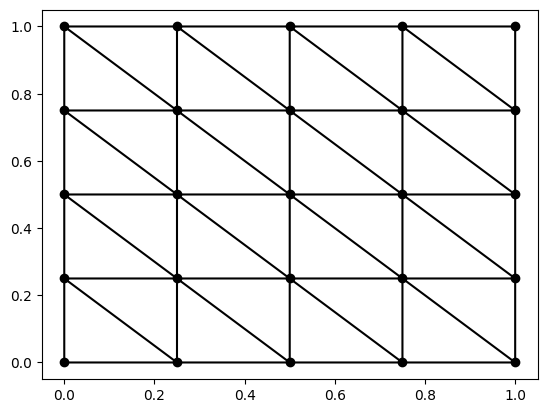

In [16]:
from import_hack import *
from methodsnm.mesh_2d import *
from methodsnm.visualize import *
mesh = StructuredRectangleMesh(4,4)
DrawMesh2D(mesh)

from methodsnm.fes import *
fes = P2_Triangle_Space(mesh)

In [17]:
from numpy.linalg import det, inv
for elnr, verts in enumerate(mesh.elements()):
    potins = mesh.points[verts]
    verts = fes._element_dofs(elnr)
    print(f"Element {elnr}:" , verts, "coordinates:", potins)

Element 0: [ 0  1  5 65 45 25] coordinates: [[0.   0.  ]
 [0.25 0.  ]
 [0.   0.25]]
Element 1: [ 5  6 10 69 46 29] coordinates: [[0.   0.25]
 [0.25 0.25]
 [0.   0.5 ]]
Element 2: [10 11 15 73 47 33] coordinates: [[0.   0.5 ]
 [0.25 0.5 ]
 [0.   0.75]]
Element 3: [15 16 20 77 48 37] coordinates: [[0.   0.75]
 [0.25 0.75]
 [0.   1.  ]]
Element 4: [ 1  2  6 66 49 26] coordinates: [[0.25 0.  ]
 [0.5  0.  ]
 [0.25 0.25]]
Element 5: [ 6  7 11 70 50 30] coordinates: [[0.25 0.25]
 [0.5  0.25]
 [0.25 0.5 ]]
Element 6: [11 12 16 74 51 34] coordinates: [[0.25 0.5 ]
 [0.5  0.5 ]
 [0.25 0.75]]
Element 7: [16 17 21 78 52 38] coordinates: [[0.25 0.75]
 [0.5  0.75]
 [0.25 1.  ]]
Element 8: [ 2  3  7 67 53 27] coordinates: [[0.5  0.  ]
 [0.75 0.  ]
 [0.5  0.25]]
Element 9: [ 7  8 12 71 54 31] coordinates: [[0.5  0.25]
 [0.75 0.25]
 [0.5  0.5 ]]
Element 10: [12 13 17 75 55 35] coordinates: [[0.5  0.5 ]
 [0.75 0.5 ]
 [0.5  0.75]]
Element 11: [17 18 22 79 56 39] coordinates: [[0.5  0.75]
 [0.75 0.75]
 [0.

In [18]:
def mittelpunkt(p1,p2):
    return (p1[0]+p2[0])/2, (p1[1]+p2[1])/2

print("Number of dofs:", fes.ndof)
print(mesh.bndry_edges)

# Dictionary: Index -> Point-Koordinaten
edge_points_dict = {}

for v in mesh.bndry_edges:
    ed = mesh.edges[v]
    dof_index = v + len(mesh.vertices)
    point = mittelpunkt(mesh.points[ed[0]], mesh.points[ed[1]])
    edge_points_dict[dof_index] = point
    print(f"DOF Index: {dof_index}, Point: {point}")


Number of dofs: 81
[0, 1, 2, 3, 36, 37, 38, 39, 19, 18, 17, 16, 23, 22, 21, 20]
DOF Index: 25, Point: (0.125, 0.0)
DOF Index: 26, Point: (0.375, 0.0)
DOF Index: 27, Point: (0.625, 0.0)
DOF Index: 28, Point: (0.875, 0.0)
DOF Index: 61, Point: (1.0, 0.125)
DOF Index: 62, Point: (1.0, 0.375)
DOF Index: 63, Point: (1.0, 0.625)
DOF Index: 64, Point: (1.0, 0.875)
DOF Index: 44, Point: (0.875, 1.0)
DOF Index: 43, Point: (0.625, 1.0)
DOF Index: 42, Point: (0.375, 1.0)
DOF Index: 41, Point: (0.125, 1.0)
DOF Index: 48, Point: (0.0, 0.875)
DOF Index: 47, Point: (0.0, 0.625)
DOF Index: 46, Point: (0.0, 0.375)
DOF Index: 45, Point: (0.0, 0.125)


In [19]:
def filter_bndry_dofs(edge_points_dict, extreme_type, coord_index):
    """
    Filtert die DOF-Indizes basierend auf extremalen Punkten.
    Gibt die Indizes zurück, die übrig bleiben.
    """
    if not edge_points_dict:
        return []
    
    points_list = list(edge_points_dict.values())
    
    if extreme_type == "min":
        target_value = min(p[coord_index] for p in points_list)
    elif extreme_type == "max":
        target_value = max(p[coord_index] for p in points_list)
    else:
        raise ValueError("extreme_type must be either 'min' or 'max'")
    
    # Gib nur die Indizes zurück, deren Punkte das Kriterium erfüllen
    return [dof_idx for dof_idx, point in edge_points_dict.items() 
            if point[coord_index] == target_value]

# Anwendung:
top =  filter_bndry_dofs(edge_points_dict, "max", 1)
bottom = filter_bndry_dofs(edge_points_dict, "min", 1)
left = filter_bndry_dofs(edge_points_dict, "min", 0)
right = filter_bndry_dofs(edge_points_dict, "max", 0)

print("Top DOFs:", top)
print("Bottom DOFs:", bottom)
print("Left DOFs:", left)
print("Right DOFs:", right)

# Am Ende kannst du damit die freedofs definieren:
edge_bndry =  bottom + left + right
print("Edge boundary DOFs:", edge_bndry)
top = mesh.filter_bndry_points("max", 1)
bottom = mesh.filter_bndry_points("min", 1)
left = mesh.filter_bndry_points("min", 0)
right = mesh.filter_bndry_points("max", 0)
bndry = left + right + bottom + edge_bndry

Top DOFs: [44, 43, 42, 41]
Bottom DOFs: [25, 26, 27, 28]
Left DOFs: [48, 47, 46, 45]
Right DOFs: [61, 62, 63, 64]
Edge boundary DOFs: [25, 26, 27, 28, 48, 47, 46, 45, 61, 62, 63, 64]


81 [6, 7, 8, 11, 12, 13, 16, 17, 18, 21, 22, 23, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80] [0, 20, 15, 10, 5, 4, 9, 14, 19, 24, 0, 1, 2, 3, 4, 25, 26, 27, 28, 48, 47, 46, 45, 61, 62, 63, 64]
L2 difference: 0.004862270173948539


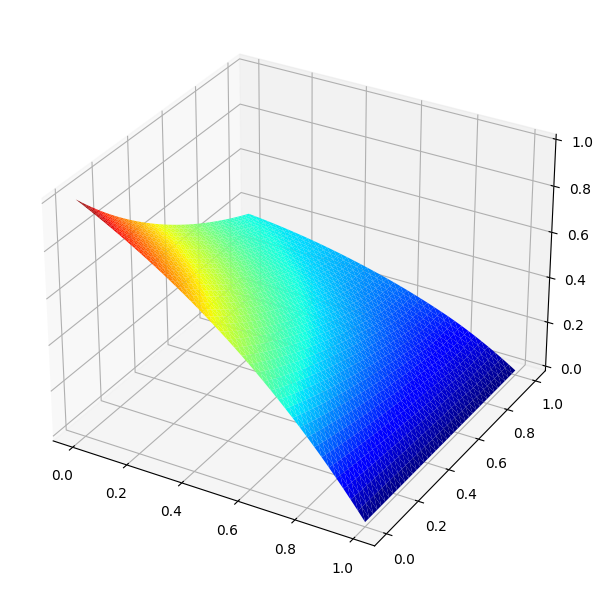

In [20]:
from methodsnm.formint import *
from methodsnm.forms import *
from numpy import exp, array    
def list_diff(a, b):
    """Entfernt alle Elemente aus Liste a, die in Liste b enthalten sind."""
    return [x for x in a if x not in b]

epsi = 1
wind = 1
eps = GlobalFunction(lambda x: epsi, mesh = mesh)
w = ConstantVectorFunction(array([wind, 1]), mesh = mesh)

blf = BilinearForm(fes)
blf += LaplaceIntegral_without_time(eps)
blf += ConvectionIntegral(w)
blf += SUPGIntegral(w)
blf.assemble()

f = lambda x: -(1 - exp((x[0] - 1)/epsi)) / (1 - exp(-1/epsi))* exp(-x[1])
f = GlobalFunction(f, mesh = mesh)
lf = LinearForm(fes)
lf += SourceIntegral(f)
lf += SUPGSourceIntegral(f, w)
lf.assemble()

freedofs = list_diff(fes.dof, bndry)
uex = lambda x: (1 - exp((x[0] - 1)/epsi)) / (1 - exp(-1/epsi))* exp(-x[1])
uh = FEFunction(fes)
uh._set_P2(uex, bndry)
print(fes.ndof,freedofs,bndry)

from methodsnm.solver import *
res = lf.vector - blf.matrix.dot(uh.vector)
uh.vector += solve_on_freedofs(blf.matrix, res, freedofs)
from methodsnm.forms import compute_difference_L2
u_exact = GlobalFunction(uex, mesh = mesh)
l2diff = compute_difference_L2(uh, u_exact, mesh, intorder = 5)
print("L2 difference:", l2diff)
DrawFunction2D(uh)